# Credit Card Fraud Detection – MLOps Final Project

## Objective
The objective of this project is to build and operationalize an XGBoost binary classification model capable of identifying fraudulent credit card transactions.

The project covers:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Class imbalance handling
- XGBoost model development
- Hyperparameter tuning
- Model evaluation
- FastAPI deployment
- Docker containerization
- CI/CD using GitHub Actions
- Model monitoring and retraining

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (284807, 31)


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -

In [5]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())
print("Duplicate rows:", df.duplicated().sum())

missing_values[missing_values > 0]

Total missing values: 0
Duplicate rows: 1081


Series([], dtype: int64)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_summary.index = ["Legitimate (0)", "Fraud (1)"]

class_summary

,Count,Percentage
Legitimate (0),284315,99.827251
Fraud (1),492,0.172749


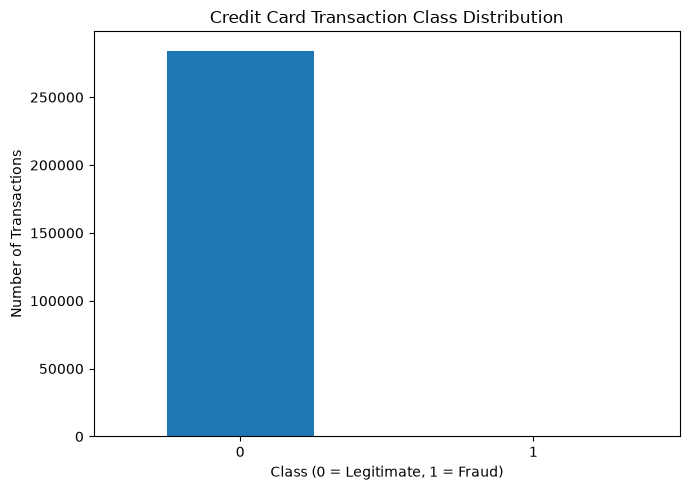

In [8]:
plt.figure(figsize=(7, 5))

class_counts.plot(kind="bar")

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

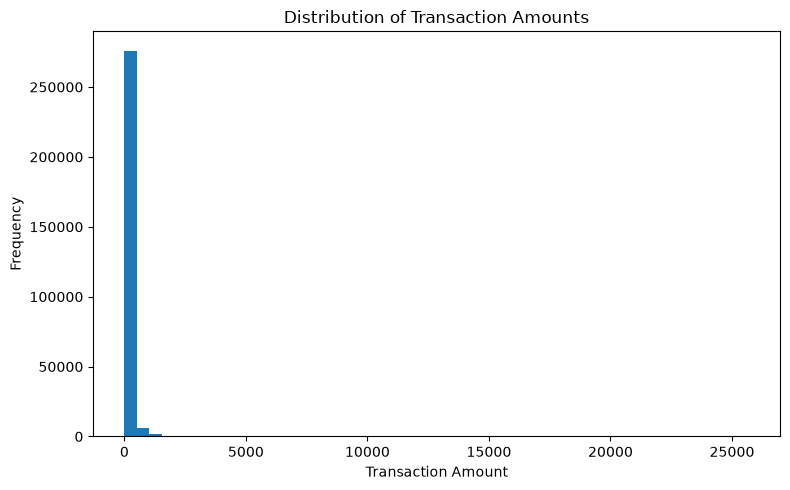

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_summary.index = ["Legitimate", "Fraud"]

amount_summary

,count,mean,median,min,max
Legitimate,284315,88.291022,22.00,0.0,25691.16
Fraud,492,122.211321,9.25,0.0,2125.87


In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature matrix: (284807, 30)
Target: (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nFraud cases:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training set: (199364, 30)
Validation set: (42721, 30)
Test set: (42722, 30)

Fraud cases:
Train: 344
Validation: 74
Test: 74


In [13]:
# Standardize Time and Amount
scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Time and Amount standardized successfully.")

Time and Amount standardized successfully.


In [14]:
# Calculate class weight for XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate training transactions:", negative_count)
print("Fraud training transactions:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Legitimate training transactions: 199020
Fraud training transactions: 344
scale_pos_weight: 578.55


## XGBoost Model Development

An XGBoost classifier is trained to detect fraudulent transactions. Because the
dataset is highly imbalanced, `scale_pos_weight` is used to give greater
importance to the minority fraud class. Model performance is evaluated using
precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [15]:
# Baseline XGBoost
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

print("Baseline XGBoost model trained successfully.")

Baseline XGBoost model trained successfully.


In [16]:
# Validation predictions
y_val_pred = baseline_model.predict(X_val)
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

print("Validation predictions generated.")

Validation predictions generated.


In [17]:
# Baseline evaluation
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("Baseline XGBoost Validation Results")
print("-----------------------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

Baseline XGBoost Validation Results
-----------------------------------
Precision : 0.7468
Recall    : 0.7973
F1-Score  : 0.7712
ROC-AUC   : 0.9831

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9995    0.9996     42647
           1     0.7468    0.7973    0.7712        74

    accuracy                         0.9992     42721
   macro avg     0.8732    0.8984    0.8854     42721
weighted avg     0.9992    0.9992    0.9992     42721



Confusion Matrix:
[[42627    20]
 [   15    59]]


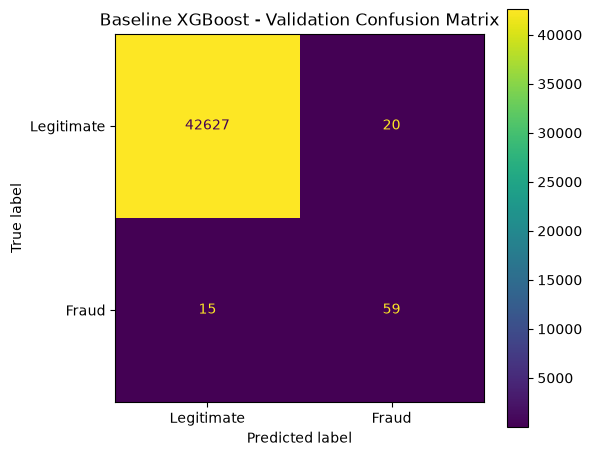

In [18]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

display = __import__(
    "sklearn.metrics",
    fromlist=["ConfusionMatrixDisplay"]
).ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

display.plot(ax=ax, values_format="d")
plt.title("Baseline XGBoost - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

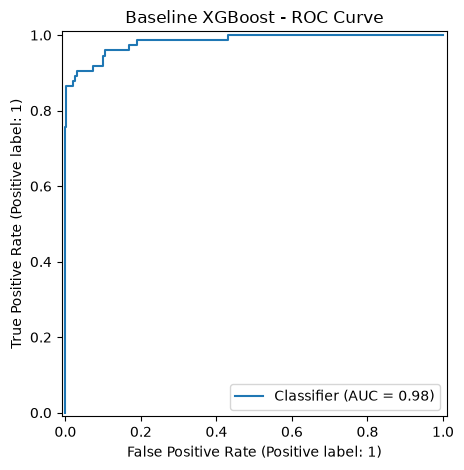

In [19]:
# ROC curve
RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title("Baseline XGBoost - ROC Curve")
plt.tight_layout()
plt.show()

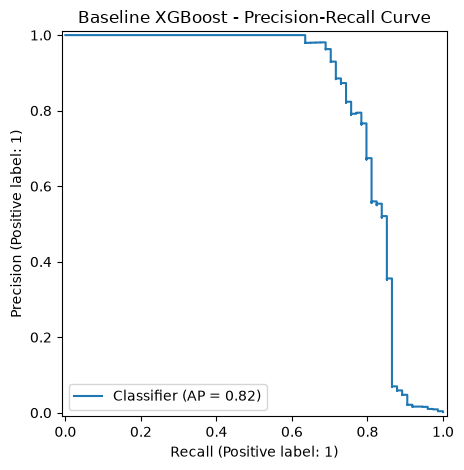

In [20]:
# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title("Baseline XGBoost - Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [21]:
# Parameter search
param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_search_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\nHyperparameter tuning completed.")
print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation score:")
print(round(random_search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Hyperparameter tuning completed.
Best parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Best cross-validation score:
0.8511


In [22]:
# Best model
best_model = random_search.best_estimator_

y_val_best_pred = best_model.predict(X_val)
y_val_best_prob = best_model.predict_proba(X_val)[:, 1]

best_precision = precision_score(y_val, y_val_best_pred)
best_recall = recall_score(y_val, y_val_best_pred)
best_f1 = f1_score(y_val, y_val_best_pred)
best_roc_auc = roc_auc_score(y_val, y_val_best_prob)

print("Tuned XGBoost Validation Results")
print("--------------------------------")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1-Score  : {best_f1:.4f}")
print(f"ROC-AUC   : {best_roc_auc:.4f}")

Tuned XGBoost Validation Results
--------------------------------
Precision : 0.9048
Recall    : 0.7703
F1-Score  : 0.8321
ROC-AUC   : 0.9807


In [23]:
# Compare baseline and tuned models
comparison = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Tuned XGBoost"],
    "Precision": [precision, best_precision],
    "Recall": [recall, best_recall],
    "F1-Score": [f1, best_f1],
    "ROC-AUC": [roc_auc, best_roc_auc]
})

comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Baseline XGBoost,0.7468,0.7973,0.7712,0.9831
1,Tuned XGBoost,0.9048,0.7703,0.8321,0.9807


In [24]:
# Final evaluation on the untouched test set

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final XGBoost Test Results")
print("--------------------------")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Final XGBoost Test Results
--------------------------
Precision : 0.8696
Recall    : 0.8108
F1-Score  : 0.8392
ROC-AUC   : 0.9686

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     42648
           1     0.8696    0.8108    0.8392        74

    accuracy                         0.9995     42722
   macro avg     0.9346    0.9053    0.9194     42722
weighted avg     0.9994    0.9995    0.9995     42722



Final Test Confusion Matrix:
[[42639     9]
 [   14    60]]


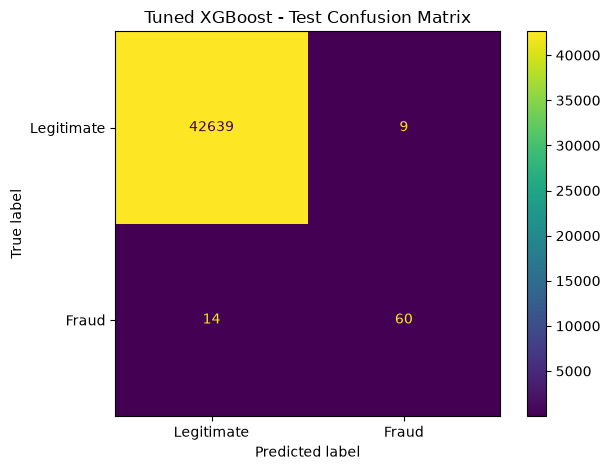

In [25]:
# Final confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

test_cm = confusion_matrix(y_test, y_test_pred)

print("Final Test Confusion Matrix:")
print(test_cm)

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["Legitimate", "Fraud"]
).plot(values_format="d")

plt.title("Tuned XGBoost - Test Confusion Matrix")
plt.tight_layout()
plt.show()

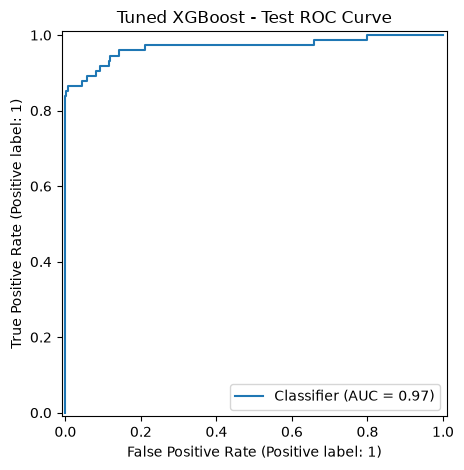

In [26]:
# Final ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("Tuned XGBoost - Test ROC Curve")
plt.tight_layout()
plt.show()

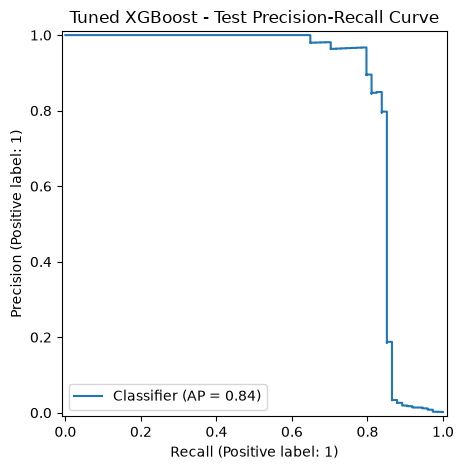

In [27]:
# Final Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("Tuned XGBoost - Test Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [28]:
# Save XGBoost model
import os
import joblib

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "xgboost_fraud_model.pkl"
)

joblib.dump(best_model, model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
../models/xgboost_fraud_model.pkl


In [29]:
# Save scaler
scaler_path = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)

joblib.dump(scaler, scaler_path)

print("Scaler saved successfully:")
print(scaler_path)

Scaler saved successfully:
../models/scaler.pkl


In [30]:
# Save feature information
feature_info = {
    "features": X.columns.tolist(),
    "scaled_features": ["Time", "Amount"],
    "target": "Class",
    "threshold": 0.5
}

feature_path = os.path.join(
    MODEL_DIR,
    "feature_info.pkl"
)

joblib.dump(feature_info, feature_path)

print("Feature information saved successfully.")
print("Number of model features:", len(feature_info["features"]))
print(feature_info["features"])

Feature information saved successfully.
Number of model features: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [31]:
# Verify everything can be loaded
loaded_model = joblib.load("../models/xgboost_fraud_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")
loaded_features = joblib.load("../models/feature_info.pkl")

print("Deployment artifacts loaded successfully.")
print("Model:", type(loaded_model).__name__)
print("Scaler:", type(loaded_scaler).__name__)
print("Number of features:", len(loaded_features["features"]))

Deployment artifacts loaded successfully.
Model: XGBClassifier
Scaler: StandardScaler
Number of features: 30


In [32]:
# Test saved model
loaded_predictions = loaded_model.predict(X_test)

same_predictions = np.array_equal(
    y_test_pred,
    loaded_predictions
)

print(
    "Loaded model predictions match original:",
    same_predictions
)

Loaded model predictions match original: True


In [33]:
# Save final metrics
final_metrics = {
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1_score": float(test_f1),
    "roc_auc": float(test_roc_auc)
}

joblib.dump(
    final_metrics,
    "../models/final_metrics.pkl"
)

print("Final metrics saved:")
final_metrics

Final metrics saved:


{'precision': 0.8695652173913043,
 'recall': 0.8108108108108109,
 'f1_score': 0.8391608391608392,
 'roc_auc': 0.9686173934204322}

In [34]:
# Get one real fraudulent transaction for API testing

fraud_sample = df[df["Class"] == 1].iloc[0]

api_sample = fraud_sample.drop("Class").to_dict()

api_sample

{'Time': 406.0,
 'V1': -2.3122265423263,
 'V2': 1.95199201064158,
 'V3': -1.60985073229769,
 'V4': 3.9979055875468,
 'V5': -0.522187864667764,
 'V6': -1.42654531920595,
 'V7': -2.53738730624579,
 'V8': 1.39165724829804,
 'V9': -2.77008927719433,
 'V10': -2.77227214465915,
 'V11': 3.20203320709635,
 'V12': -2.89990738849473,
 'V13': -0.595221881324605,
 'V14': -4.28925378244217,
 'V15': 0.389724120274487,
 'V16': -1.14074717980657,
 'V17': -2.83005567450437,
 'V18': -0.0168224681808257,
 'V19': 0.416955705037907,
 'V20': 0.126910559061474,
 'V21': 0.517232370861764,
 'V22': -0.0350493686052974,
 'V23': -0.465211076182388,
 'V24': 0.320198198514526,
 'V25': 0.0445191674731724,
 'V26': 0.177839798284401,
 'V27': 0.261145002567677,
 'V28': -0.143275874698919,
 'Amount': 0.0}

In [35]:
import json

fraud_sample = df[df["Class"] == 1].iloc[0]

api_sample = {
    key: float(value)
    for key, value in fraud_sample.drop("Class").items()
}

json_request = json.dumps(api_sample, indent=2)

print(json_request)

{
  "Time": 406.0,
  "V1": -2.3122265423263,
  "V2": 1.95199201064158,
  "V3": -1.60985073229769,
  "V4": 3.9979055875468,
  "V5": -0.522187864667764,
  "V6": -1.42654531920595,
  "V7": -2.53738730624579,
  "V8": 1.39165724829804,
  "V9": -2.77008927719433,
  "V10": -2.77227214465915,
  "V11": 3.20203320709635,
  "V12": -2.89990738849473,
  "V13": -0.595221881324605,
  "V14": -4.28925378244217,
  "V15": 0.389724120274487,
  "V16": -1.14074717980657,
  "V17": -2.83005567450437,
  "V18": -0.0168224681808257,
  "V19": 0.416955705037907,
  "V20": 0.126910559061474,
  "V21": 0.517232370861764,
  "V22": -0.0350493686052974,
  "V23": -0.465211076182388,
  "V24": 0.320198198514526,
  "V25": 0.0445191674731724,
  "V26": 0.177839798284401,
  "V27": 0.261145002567677,
  "V28": -0.143275874698919,
  "Amount": 0.0
}
